# Hourly FWI on an xarray grid

This notebook compares the existing station-by-station calculation with the private xarray/Numba grid calculation. It uses one complete non-leap year (8,760 hourly timesteps), starts with a 2×2 correctness example, and then measures scaling with the number of grid cells.

The weather dataset already contains sunrise, sunset, solar radiation, curing, and grass fuel load. This keeps the benchmark focused on the stateful FWI calculation itself. Each cell has its own startup state.


In [ ]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numba
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.notebook import tqdm

python_candidates = [
    os.getcwd(),
    os.path.abspath(os.path.join(os.getcwd(), "..")),
    os.path.abspath(os.path.join(os.getcwd(), "FWI", "Python")),
]
PYTHON_DIR = next(
    candidate
    for candidate in python_candidates
    if os.path.exists(os.path.join(candidate, "NG_FWI.py"))
)
if PYTHON_DIR not in sys.path:
    sys.path.insert(0, PYTHON_DIR)

import NG_FWI

print(
    f"NumPy {np.__version__}; Numba {numba.__version__}; {numba.get_num_threads()} Numba threads"
)

NumPy 2.3.2; Numba 0.62.0; 16 Numba threads


In [10]:
def make_mock_weather(n_lat, n_lon, seed=2026):
    time_index = pd.date_range("2025-01-01", periods=365 * 24, freq="h")
    lat = np.linspace(51.0, 53.0, n_lat)
    lon = np.linspace(4.0, 6.0, n_lon)
    shape = (len(time_index), n_lat, n_lon)
    rng = np.random.default_rng(seed)

    day = time_index.dayofyear.to_numpy()[:, None, None]
    hour = time_index.hour.to_numpy()[:, None, None]
    lat_offset = lat[None, :, None] - 52.0
    lon_offset = lon[None, None, :] - 5.0
    seasonal = np.sin(2.0 * np.pi * (day - 172.0) / 365.0)
    diurnal = np.sin(2.0 * np.pi * (hour - 8.0) / 24.0)

    temp = 12.0 + 10.0 * seasonal + 4.0 * diurnal - lat_offset + lon_offset
    temp = np.broadcast_to(temp, shape).copy() + rng.normal(0.0, 0.5, shape)
    rh = np.clip(65.0 - 18.0 * diurnal - 8.0 * seasonal + 2.0 * lat_offset, 15.0, 100.0)
    rh = np.broadcast_to(rh, shape).copy()
    ws = np.clip(12.0 + 3.0 * diurnal + lon_offset, 0.0, None)
    ws = np.broadcast_to(ws, shape).copy()

    rain_event = rng.random(shape) < 0.015
    prec = np.where(rain_event, rng.gamma(1.4, 1.2, shape), 0.0)
    daylight_season = np.sin(2.0 * np.pi * (day - 80.0) / 365.0)
    sunrise = 7.0 - 2.0 * daylight_season + 0.05 * lat_offset
    sunset = 19.0 + 2.0 * daylight_season - 0.05 * lat_offset
    sunrise = np.broadcast_to(sunrise, shape).copy()
    sunset = np.broadcast_to(sunset, shape).copy()
    solar_phase = (hour - sunrise) / (sunset - sunrise)
    solrad = 0.75 * np.maximum(np.sin(np.pi * solar_phase), 0.0)
    solrad[(hour < sunrise) | (hour > sunset)] = 0.0
    percent_cured = np.clip(
        70.0 + 22.0 * np.cos(2.0 * np.pi * (day - 20.0) / 365.0), 20.0, 96.0
    )
    percent_cured = np.broadcast_to(percent_cured, shape).copy()
    grass_fuel_load = 0.35 + 0.01 * (lat[:, None] - 52.0) + 0.005 * (lon[None, :] - 5.0)

    return xr.Dataset(
        {
            "temp": (("time", "lat", "lon"), temp),
            "rh": (("time", "lat", "lon"), rh),
            "ws": (("time", "lat", "lon"), ws),
            "prec": (("time", "lat", "lon"), prec),
            "solrad": (("time", "lat", "lon"), solrad),
            "sunrise": (("time", "lat", "lon"), sunrise),
            "sunset": (("time", "lat", "lon"), sunset),
            "percent_cured": (("time", "lat", "lon"), percent_cured),
            "grass_fuel_load": (("lat", "lon"), grass_fuel_load),
        },
        coords={"time": time_index, "lat": lat, "lon": lon},
    )


def make_startup_state(ds_wx):
    lat_index = xr.DataArray(
        np.arange(ds_wx.sizes["lat"]), coords={"lat": ds_wx.lat}, dims="lat"
    )
    lon_index = xr.DataArray(
        np.arange(ds_wx.sizes["lon"]), coords={"lon": ds_wx.lon}, dims="lon"
    )
    cell_index = lat_index + lon_index
    return {
        "ffmc_old": 82.0 - 1.5 * cell_index,
        "dmc_old": 6.0 + 2.0 * cell_index,
        "dc_old": 15.0 + 8.0 * cell_index,
        "mcgfmc_matted_old": 16.0 + 0.5 * cell_index,
        "mcgfmc_standing_old": 15.0 + 0.4 * cell_index,
        "prec_cumulative": xr.zeros_like(cell_index, dtype=float),
        "canopy_drying": xr.zeros_like(cell_index, dtype=float),
    }

In [11]:
def _state_at(startup, name, lat_i, lon_i):
    value = startup[name]
    if isinstance(value, xr.DataArray):
        return value.isel(lat=lat_i, lon=lon_i).item()
    return value


def legacy_grid(ds_wx, startup):
    output = np.empty(
        (
            len(NG_FWI._GRID_OUTPUT_VARIABLES),
            ds_wx.sizes["time"],
            ds_wx.sizes["lat"],
            ds_wx.sizes["lon"],
        )
    )
    timestamp = pd.DatetimeIndex(ds_wx.time.values)
    for lat_i, lat_value in enumerate(ds_wx.lat.values):
        for lon_i, lon_value in enumerate(ds_wx.lon.values):
            cell = ds_wx.isel(lat=lat_i, lon=lon_i)
            weather = pd.DataFrame(
                {
                    "id": f"{lat_i}-{lon_i}",
                    "lat": lat_value,
                    "long": lon_value,
                    "timezone": 1.0,
                    "yr": timestamp.year,
                    "mon": timestamp.month,
                    "day": timestamp.day,
                    "hr": timestamp.hour,
                    "minute": timestamp.minute,
                    "timestamp": timestamp,
                    "date": timestamp.date,
                    "temp": cell.temp.values,
                    "rh": cell.rh.values,
                    "ws": cell.ws.values,
                    "prec": cell.prec.values,
                    "solrad": cell.solrad.values,
                    "sunrise": cell.sunrise.values,
                    "sunset": cell.sunset.values,
                    "sunlight_hours": cell.sunset.values - cell.sunrise.values,
                    "percent_cured": cell.percent_cured.values,
                    "grass_fuel_load": cell.grass_fuel_load.item(),
                }
            )
            result = NG_FWI._stnHFWI(
                weather,
                _state_at(startup, "ffmc_old", lat_i, lon_i),
                None,
                _state_at(startup, "dmc_old", lat_i, lon_i),
                _state_at(startup, "dc_old", lat_i, lon_i),
                _state_at(startup, "mcgfmc_matted_old", lat_i, lon_i),
                _state_at(startup, "mcgfmc_standing_old", lat_i, lon_i),
                _state_at(startup, "prec_cumulative", lat_i, lon_i),
                _state_at(startup, "canopy_drying", lat_i, lon_i),
            )
            output[:, :, lat_i, lon_i] = (
                result[list(NG_FWI._GRID_OUTPUT_VARIABLES)].to_numpy().T
            )

    return xr.Dataset(
        {
            name: (("time", "lat", "lon"), output[i])
            for i, name in enumerate(NG_FWI._GRID_OUTPUT_VARIABLES)
        },
        coords=ds_wx.coords,
    )

## Correctness and timing

The first compiled call is a 24-hour warm-up and is excluded from timing. Every timed optimized result is checked against independently calculated stations before its timing is cached.


In [ ]:
warm_weather = make_mock_weather(1, 1).isel(time=slice(0, 24))
NG_FWI._hFWI(warm_weather, **make_startup_state(warm_weather))

# benchmark_cache = {}
for side in tqdm(np.arange(1, 21)):
    weather = make_mock_weather(side, side)
    startup = make_startup_state(weather)

    start = time.perf_counter()
    legacy = legacy_grid(weather, startup)
    legacy_seconds = time.perf_counter() - start

    start = time.perf_counter()
    optimized = NG_FWI._hFWI(weather, **startup)
    optimized_seconds = time.perf_counter() - start

    optimized_outputs = optimized[list(NG_FWI._GRID_OUTPUT_VARIABLES)]
    xr.testing.assert_allclose(optimized_outputs, legacy, rtol=1e-12, atol=1e-12)
    benchmark_cache[side] = {
        "grid": f"{side}x{side}",
        "grid_cells": side * side,
        "legacy_seconds": legacy_seconds,
        "optimized_seconds": optimized_seconds,
        "speedup": legacy_seconds / optimized_seconds,
        "legacy": legacy,
        "optimized": optimized_outputs,
    }

timings = pd.DataFrame(
    [
        {
            key: value
            for key, value in item.items()
            if key not in {"legacy", "optimized"}
        }
        for item in benchmark_cache.values()
    ]
)
timings

  0%|          | 0/10 [00:00<?, ?it/s]

,grid,grid_cells,legacy_seconds,optimized_seconds,speedup
0,1x1,1,1.286807,0.049111,26.201818
1,2x2,4,5.225645,0.050402,103.678785
2,3x3,9,11.534201,0.051456,224.158651
3,4x4,16,20.593574,0.067272,306.123922
4,5x5,25,32.242124,0.093246,345.775017
5,6x6,36,46.356602,0.080810,573.651184
6,7x7,49,62.861498,0.090883,691.672995
7,8x8,64,82.123639,0.113155,725.760563
8,9x9,81,103.990829,0.141416,735.355340
9,10x10,100,128.569361,0.138319,929.512148


<xarray.Dataset> Size: 168B
Dimensions:  (lat: 2, lon: 2)
Coordinates:
  * lat      (lat) float64 16B 51.0 53.0
  * lon      (lon) float64 16B 4.0 6.0
    time     datetime64[us] 8B 2025-12-31T23:00:00
Data variables:
    ffmc     (lat, lon) float64 32B 84.4 84.62 82.35 83.52
    dmc      (lat, lon) float64 32B 42.45 87.35 29.13 22.94
    dc       (lat, lon) float64 32B 916.3 1.106e+03 924.4 926.2
    fwi      (lat, lon) float64 32B 11.35 17.41 7.303 7.92

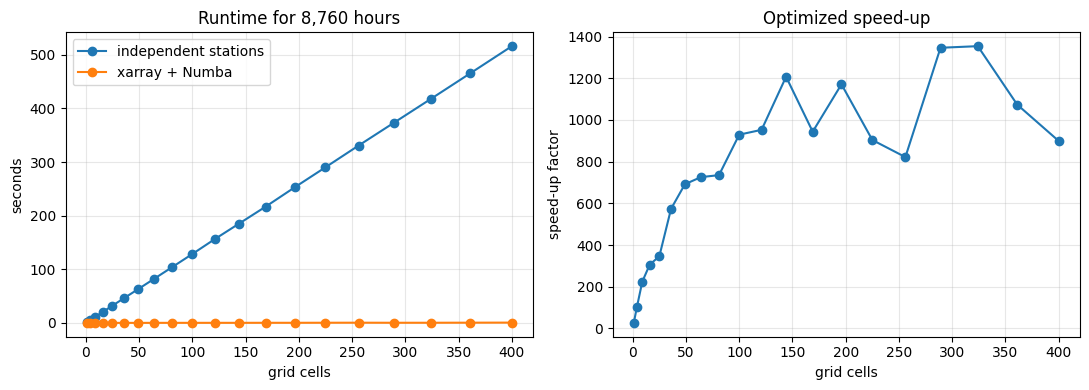

In [15]:
# The requested minimal 2x2 case passed the full-year equality assertion above.
minimal = benchmark_cache[2]
display(minimal["optimized"][["ffmc", "dmc", "dc", "fwi"]].isel(time=-1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    timings.grid_cells, timings.legacy_seconds, "o-", label="independent stations"
)
axes[0].plot(
    timings.grid_cells, timings.optimized_seconds, "o-", label="xarray + Numba"
)
axes[0].set(xlabel="grid cells", ylabel="seconds", title="Runtime for 8,760 hours")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(timings.grid_cells, timings.speedup, "o-")
axes[1].set(xlabel="grid cells", ylabel="speed-up factor", title="Optimized speed-up")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()